In [19]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

np.random.seed(42)

In [20]:
df = pd.read_csv('homework_2.1.csv')
df

,time,G1,G2,G3
0,0,0.882026,1.441575,0.065409
1,1,0.210079,-0.163880,0.140310
2,2,0.509369,-0.115242,0.819830
3,3,1.150447,1.014698,0.607632
4,4,0.973779,-0.046562,0.610066
...,...,...,...,...
95,95,1.303287,1.364227,1.768446
96,96,0.965250,1.845895,1.258862
97,97,1.862935,1.881752,1.511477
98,98,1.043456,2.561618,1.030275


For questions 1 and 2: 

Do a regression to estimate the fixed effect of each group. We assume that there is one single linear coefficient for all the data, plus the fixed effect of each group. Use the file homework_2.1.csv.  The variables G1, G2, and G3 are the outcomes and the time is the treatment.

In [21]:
# transform from the 3 column to single col with 3 value
df_long = pd.melt(
    df, 
    id_vars=['time'], 
    value_vars=['G1', 'G2', 'G3'], 
    var_name='group', 
    value_name='outcome'
)

# landed on this model but wasn't totally sure which is the right way based on course notes/online resource
model = smf.ols(formula="outcome ~ time + C(group)", data=df_long).fit()
# model = smf.ols(formula="outcome ~ time + C(group) - 1", data=df_long).fit()
# model = smf.ols(formula="outcome ~ time * C(group)", data=df_long).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.304
Method:                 Least Squares   F-statistic:                     44.55
Date:                Thu, 18 Jun 2026   Prob (F-statistic):           8.72e-24
Time:                        12:50:51   Log-Likelihood:                -216.89
No. Observations:                 300   AIC:                             441.8
Df Residuals:                     296   BIC:                             456.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.0786      0.071      1.

In [22]:
model.params # I think intercept will be group 1?

Intercept         0.078552
C(group)[T.G2]    0.511102
C(group)[T.G3]    0.190480
time              0.009017
dtype: float64

In [23]:
common_slope = model.params['time']
group_1_data = df_long[df_long['group'] == 'G1'] # filter to group 1
group_1_coef = group_1_data['outcome'].mean() - (common_slope * group_1_data['time'].mean())
group_1_coef


np.float64(0.07855194562170326)

=== Fixed Effects for G1 ===
Coefficient on time: 0.0085
Standard error: 0.0017



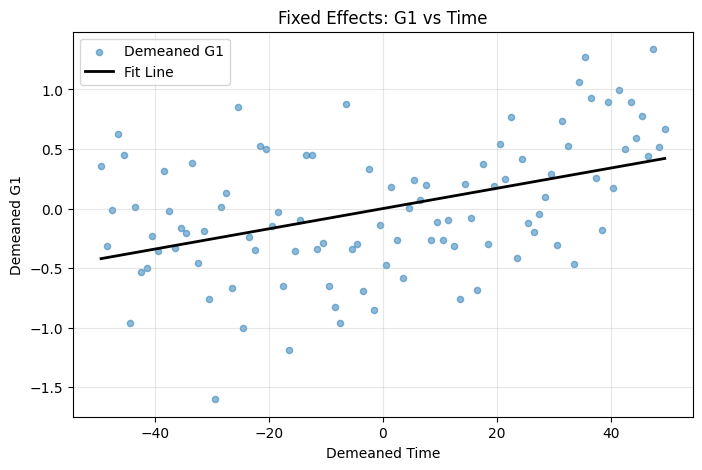

=== Fixed Effects for G2 ===
Coefficient on time: 0.0071
Standard error: 0.0018



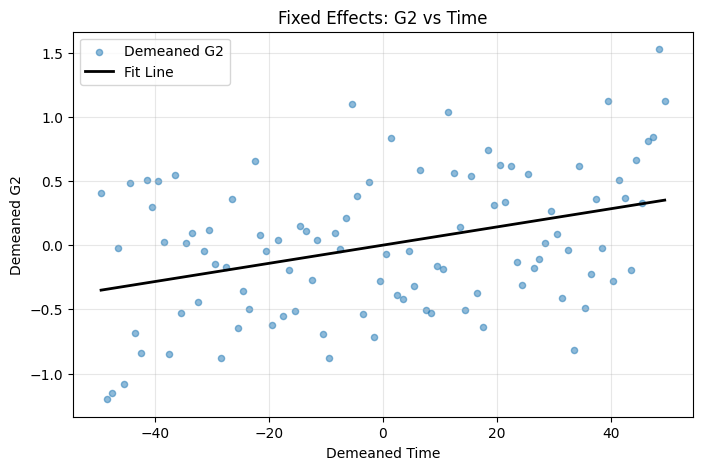

=== Fixed Effects for G3 ===
Coefficient on time: 0.0115
Standard error: 0.0017



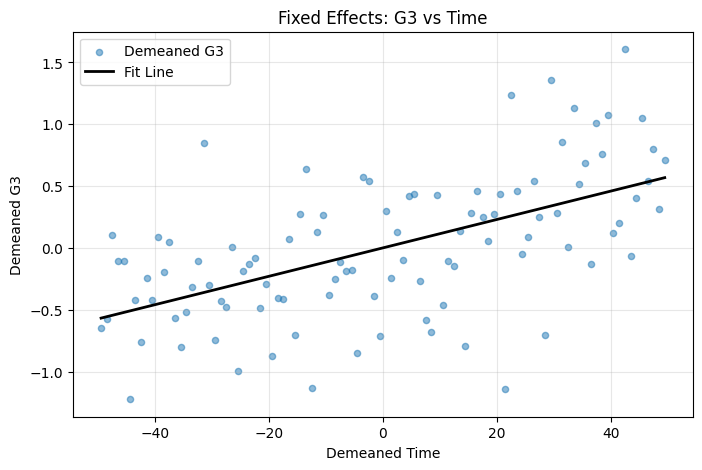

In [ ]:
# Adapted from week 3 nb

outcomes = ["G1", "G2", "G3"]

# ----------------------------
# 2) Demean the data
# ----------------------------
# Since there are no groups, we demean by subtracting the overall mean
df["time_dm"] = df["time"] - df["time"].mean()

for col in outcomes:
    df[f"{col}_dm"] = df[col] - df[col].mean()

# ----------------------------
# 3) Run Models and Plot
# ----------------------------
X_dm = df[["time_dm"]]

for col in outcomes:
    y_dm = df[f"{col}_dm"]
    fe_model = sm.OLS(y_dm, X_dm).fit()

    print(f"=== Fixed Effects for {col} ===")
    print(f"Coefficient on time: {fe_model.params['time_dm']:.4f}")
    print(f"Standard error: {fe_model.bse['time_dm']:.4f}\n")

    # Plot results
    plt.figure(figsize=(8, 5))
    plt.scatter(
        df["time_dm"], df[f"{col}_dm"], alpha=0.5, s=20, label=f"Demeaned {col}"
    )

    # Add fit line
    x_line = np.linspace(df["time_dm"].min(), df["time_dm"].max(), 200)
    y_line = fe_model.params["time_dm"] * x_line
    plt.plot(x_line, y_line, color="black", linewidth=2, label="Fit Line")

    plt.xlabel("Demeaned Time")
    plt.ylabel(f"Demeaned {col}")
    plt.title(f"Fixed Effects: {col} vs Time")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


Q1: Which of these is closest to being the coefficient of group 1? 

In [25]:
0.00850

0.0085

Q2: Which of these is closest to being the common linear coefficient for all groups?

In [26]:
0.009017

0.009017